In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv("BMW_clean_data.csv")
#Basic Dataset Overview
print("Dataset Info")
print(df.info())
print("First 5 Rows")
print(df.head())
print("Summary Statistics")
print(df.describe())

#Check for missing values
print("Missing Values")
print(df.isnull().sum())


#Basic Statistics (Mean, Median, Min, Max)
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    print(f"{col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")


#Detect Outliers using IQR method
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return outliers

print("Outlier Detection")
for col in numeric_cols:
    outliers = detect_outliers(df, col)
    print(f"{col}: {len(outliers)} outliers detected")


#Correlation Analysis
corr = df.corr(numeric_only=True)
print("Correlation Matrix")
print(corr)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB
None
First 5 Rows
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol     

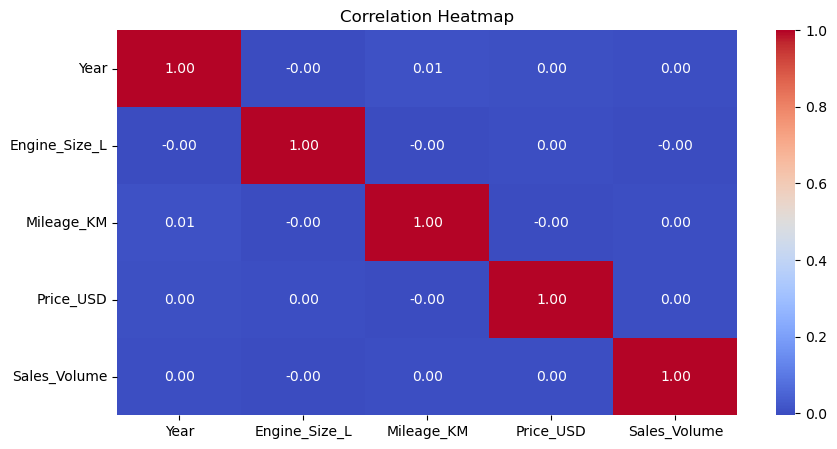

In [8]:
# Heatmap of correlations
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
# plt.savefig("Heatmap of Correlations")
plt.show()

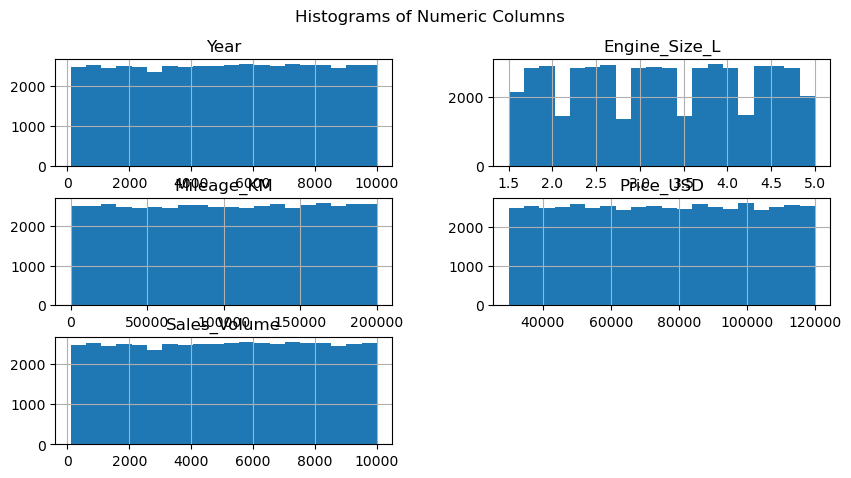

In [7]:
# Histogram for numeric columns
df[numeric_cols].hist(figsize=(10,5), bins=20)
plt.suptitle("Histograms of Numeric Columns")
# plt.savefig("Histogram for Numeric Columns")
plt.show()


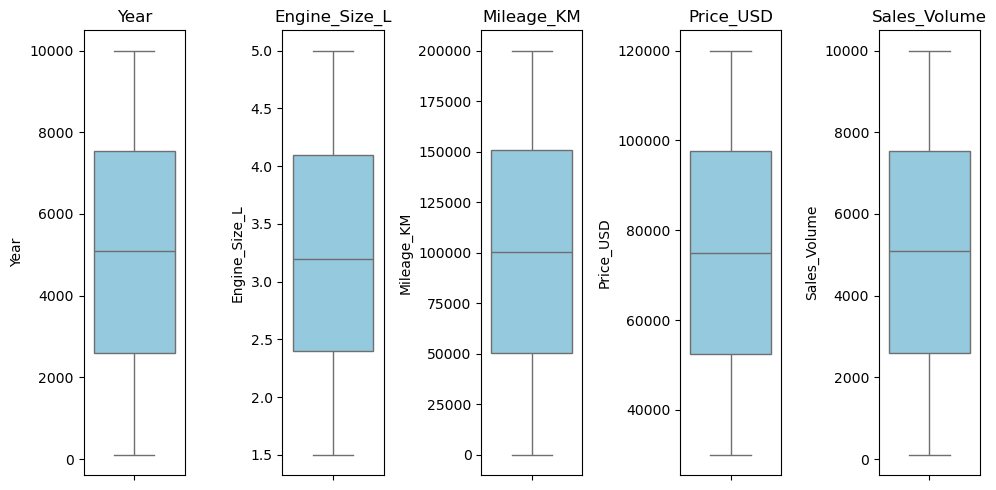

In [10]:
# Boxplots to visualize outliers
plt.figure(figsize=(10,5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
# plt.savefig("Boxplots to visualize outliers")
plt.show()

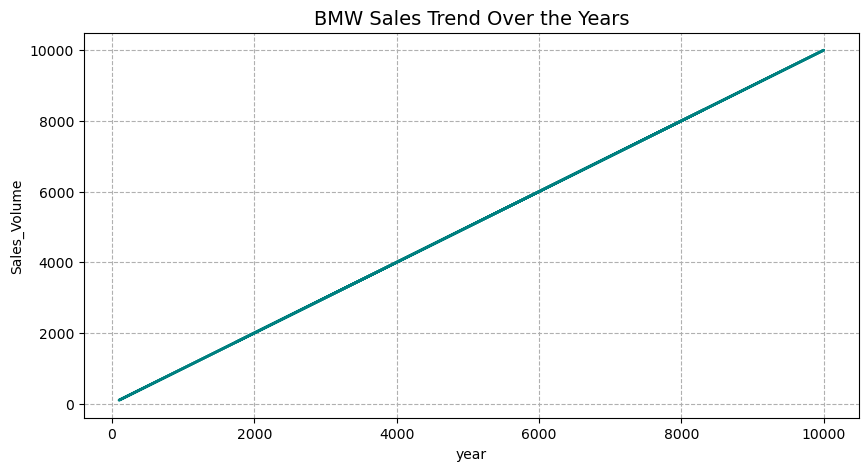

In [5]:
# Line chart for trends 
df['Year'] = pd.to_numeric(df['Sales_Volume'], errors='coerce')
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['Sales_Volume'], color='teal', linewidth=2)
plt.title("BMW Sales Trend Over the Years", fontsize=14)
plt.xlabel("year")
plt.ylabel("Sales_Volume")
plt.grid(True, linestyle='--')
# plt.savefig("Line Chart Trend Over the Year")
plt.show()

C:\Users\itsfa\AppData\Local\Temp\ipykernel_9036\901252796.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_col, y=num_col, data=df, estimator='mean', palette='viridis')


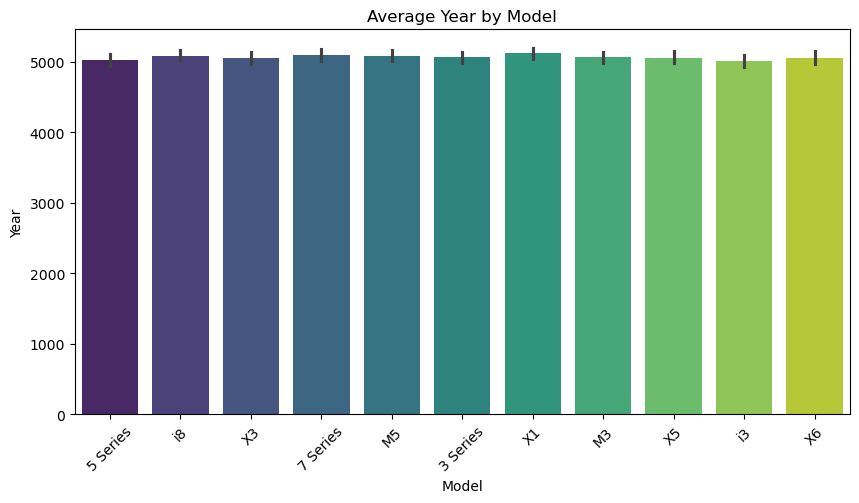

In [6]:
# Bar chart for categorical vs numeric variable
categorical_cols = df.select_dtypes(include="object").columns
if len(categorical_cols) > 0:
    cat_col = categorical_cols[0]
    num_col = numeric_cols[0]
    plt.figure(figsize=(10,5))
    sns.barplot(x=cat_col, y=num_col, data=df, estimator='mean', palette='viridis')
    plt.title(f"Average {num_col} by {cat_col}")
    plt.xticks(rotation=45)
    # plt.savefig("Bar Chart for categorical Vs Numeric Variable")
    plt.show()